# Show 4 MNIST images and 4 CIFAR-10 images
This notebook displays 4 images from the MNIST test set and 4 images from the CIFAR-10 test set in separate figures, each with their labels.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
import numpy as np

def show_row(dataset, indices, classes=None, title=None):
    fig, axes = plt.subplots(1, len(indices), figsize=(len(indices)*2.2, 2.4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        img, lbl = dataset[idx]
        img_disp = ToPILImage()(img) if not isinstance(img, np.ndarray) else img
        cmap = 'gray' if (getattr(img_disp, 'mode', None) in [None, 'L']) else None
        axes[axes.index(ax) if hasattr(axes, 'index') else list(axes).index(ax)].imshow(img_disp, cmap=cmap)
        if classes is not None:
            ax.set_title(str(classes[lbl]))
        else:
            ax.set_title(str(int(lbl)))
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

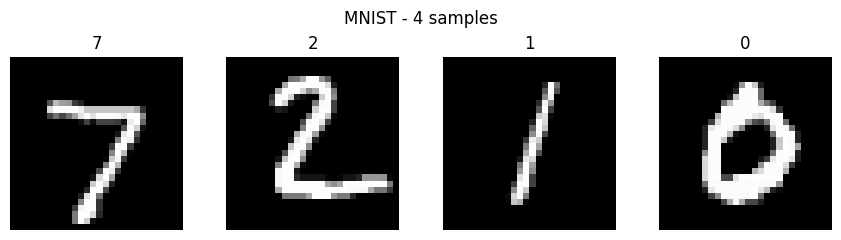

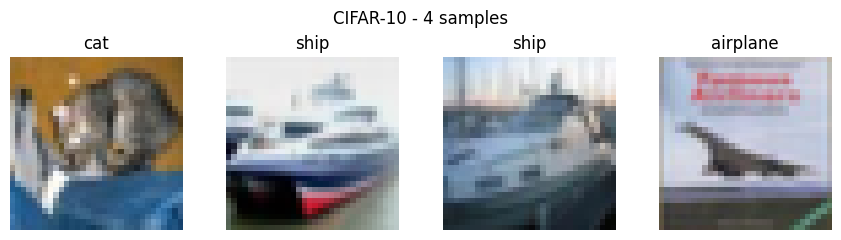

In [4]:
# Load datasets (set download=True if needed)
mnist_test = torchvision.datasets.MNIST(root='../../data', train=False, download=False, transform=transforms.ToTensor())
cifar_test = torchvision.datasets.CIFAR10(root='../../data', train=False, download=False, transform=transforms.ToTensor())
cifar_classes = cifar_test.classes
# Select 4 examples from each dataset
mnist_indices = [0, 1, 2, 3]
cifar_indices = [0, 1, 2, 3]
# Show MNIST in its own figure
show_row(mnist_test, mnist_indices, title='MNIST - 4 samples')
# Show CIFAR-10 in its own figure (use class names)
show_row(cifar_test, cifar_indices, classes=cifar_classes, title='CIFAR-10 - 4 samples')

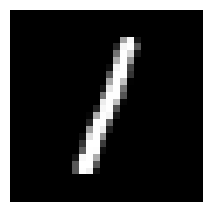

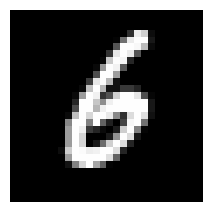

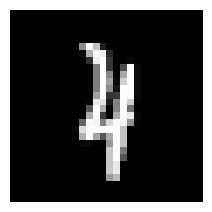

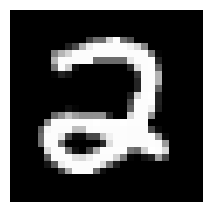

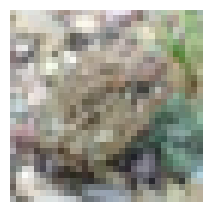

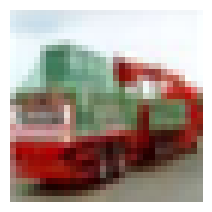

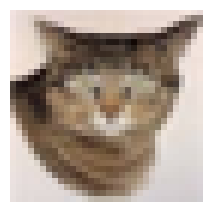

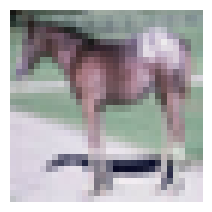

In [15]:
# Display 4 random MNIST and 4 random CIFAR images separately (no labels).
import random
# Random MNIST single-image figures
mnist_random_idx = random.sample(range(len(mnist_test)), 4)
for idx in mnist_random_idx:
    img, _ = mnist_test[idx]
    img_pil = ToPILImage()(img) if not isinstance(img, np.ndarray) else img
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img_pil, cmap='gray')
    plt.axis('off')

# Random CIFAR single-image figures
cifar_random_idx = random.sample(range(len(cifar_test)), 4)
for idx in cifar_random_idx:
    img, _ = cifar_test[idx]
    img_pil = ToPILImage()(img) if not isinstance(img, np.ndarray) else img
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img_pil)
    plt.axis('off')

# Show all generated figures
plt.show()